# scikit-learn — `train_test_split`

> 📘 **Instructor Curriculum** — M07 Machine Learning

**Status:** 🟡 Learning. This notebook covers **splitting data only**. No model is trained yet.

## What is scikit-learn?

scikit-learn is the standard Python library for **classical** machine learning —
everything before neural networks. Regression, decision trees, clustering, scaling,
encoding, and model evaluation all live here.

It sits on top of NumPy and Pandas. You hand it a table of numbers. It hands back
either a cleaned table or a prediction.

## The shape of the whole library

Every object in scikit-learn is an **estimator**, and estimators have three verbs:

```text
   .fit(X, y)        LEARN     read the data, remember what you found
   .transform(X)     RESHAPE   apply what you learned, return a new X
   .predict(X)       ANSWER    apply what you learned, return a prediction
```

Anything learned during `fit` is stored with a trailing underscore — `model.coef_`,
`scaler.mean_`. No underscore means you supplied it. Underscore means the data taught it.

`train_test_split` is not an estimator. It is a plain function. But it comes **first**,
before any estimator, and this notebook explains why.

## Step 0 — Imports


In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split

## Step 1 — Load the data

The dataset lives in the Pandas folder, one level up from here:

```text
02_data_toolkit_apps/
├── 02_pandas/
│   └── DataSet/
│       └── age1.csv        <- the file we read
└── 08_sklearn/
    └── example_01.ipynb    <- we are here
```

`../02_pandas/DataSet/age1.csv` is a **relative** path. It starts from the folder
holding this notebook. `..` steps up one level, then we walk back down.

A path starting with `/` means the root of the whole computer, not the root of this
repository. That mistake raises `FileNotFoundError` even though the file clearly exists.


In [2]:
data1 = pd.read_csv("../02_pandas/DataSet/age1.csv")
data1

,Age,Income
0,20,10000
1,30,15000
2,80,50000
3,50,30000
4,10,5000
5,45,25000
6,30,20000
7,55,35000
8,60,40000
9,70,45000


## Step 2 — Choose the input and the target

Two names, and the capitalisation is a real convention:

| Name | Meaning | Why the case |
|---|---|---|
| `X` | the **input** — what the model is allowed to see | Capital, because it is normally a 2-D table of many columns |
| `y` | the **target** — what the model must predict | Lowercase, because it is normally a single 1-D column |

Here `Age` is the input and `Income` is the target. The question being set up is:
*given a person's age, can we predict their income?*

**One thing to know for later.** `data1['Age']` returns a **Series**, which is 1-D.
`train_test_split` is happy with that. But when you later call `model.fit(X, y)`,
scikit-learn will demand a 2-D `X` and raise an error asking you to reshape.
`data1[['Age']]` — with double brackets — returns a 1-column **DataFrame**, which is
already 2-D. Not needed yet; remember it for the first model.


In [3]:
X = data1['Age']
Y = data1['Income']

## Step 3 — The split, parameter by parameter

```python
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=0, shuffle=False)
```

### Why split at all?

A model that is scored on the same rows it learned from will always look brilliant.
That is memorisation, not learning. So you hide some rows, train on the rest, and score
against the hidden ones. Those hidden rows are the only honest measure you have.

```text
   10 rows
     ↓
   SPLIT  ──→  8 train rows  ──→  the model learns from these
          └─→  2 test rows   ──→  never seen during training, used only to score
```

**Engineering view.** It is a holdout set, the same idea as keeping a validation dataset
your integration tests never train against. The moment the model sees a test row, that
row stops measuring anything.

### Every parameter

| Parameter | What it does | Default |
|---|---|---|
| `X, Y` | The arrays to split. You may pass several; each is split **the same way**, so rows stay aligned. | required |
| `test_size` | Size of the test part. A float is a fraction (`0.2` = 20%); an int is a row count. | `0.25` |
| `train_size` | The other side. Normally left alone — it is inferred from `test_size`. | `None` |
| `shuffle` | Whether to mix the rows before cutting. **This is the important one.** | `True` |
| `random_state` | Seed for the shuffling, so a "random" split is repeatable. | `None` |
| `stratify` | Keep the class balance of a column in both parts. Used for classification. | `None` |

### What it returns

Four objects, **always in this order**:

```text
   train_test_split(X, Y)  ->  X_train, X_test, y_train, y_test
                                  │        │       │        │
                                  └── X ───┘       └── Y ───┘
                                   input pair       target pair
```

Getting the order wrong is a classic bug. It does not raise an error — it just silently
trains on the wrong data. Note that it is X, X, y, y — **not** X, y, X, y.


In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2,random_state=0, shuffle=False)
# I wanted t you to test the with different values show me those outputs in different visulisation ways like changing the random state , then huffle , i wanted to explain each and every bit of this method 

## Step 4 — Read the result

Print all four parts. Watch the **index numbers** on the left of each Series — those are
the original row labels, and they tell you exactly which rows were taken.


In [5]:
print(X_train,'\n')
print(X_test,'\n')
print(y_train,'\n')
print(y_test,'\n')

0    20
1    30
2    80
3    50
4    10
5    45
6    30
7    55
Name: Age, dtype: int64 

8    60
9    70
Name: Age, dtype: int64 

0    10000
1    15000
2    50000
3    30000
4     5000
5    25000
6    20000
7    35000
Name: Income, dtype: int64 

8    40000
9    45000
Name: Income, dtype: int64 



## Step 5 — Now the experiments

You asked to see what happens with different values. Below, each parameter is changed
on its own so you can see precisely what it controls.

First a small helper that reports **which original rows** ended up in the test set.
Everything after this uses it.


In [6]:
def test_rows(**kwargs):
    """Return the original row labels that land in the test set."""
    _, X_test, _, _ = train_test_split(X, Y, **kwargs)
    return list(X_test.index)


print("your current settings ->", test_rows(test_size=0.2, random_state=0, shuffle=False))

your current settings -> [8, 9]


## Experiment 1 — `shuffle=False` makes `random_state` do nothing

Your call passes `random_state=0` **and** `shuffle=False`. These two fight each other.

`random_state` seeds the shuffling. If there is no shuffling, there is nothing to seed.
The split becomes a plain slice: *take the last 20% of the rows, in file order*.

Change the seed to anything you like and the answer will not move.


In [7]:
a = test_rows(test_size=0.2, random_state=0,   shuffle=False)
b = test_rows(test_size=0.2, random_state=99,  shuffle=False)
c = test_rows(test_size=0.2, random_state=1234, shuffle=False)

print("random_state=0    ->", a)
print("random_state=99   ->", b)
print("random_state=1234 ->", c)
print()
print("all identical:", a == b == c)
print("-> with shuffle=False, random_state is ignored completely")

random_state=0    -> [8, 9]
random_state=99   -> [8, 9]
random_state=1234 -> [8, 9]

all identical: True
-> with shuffle=False, random_state is ignored completely


**Why this matters.** `shuffle=False` is not neutral. It hands you whatever happens to
sit at the bottom of the file.

If a CSV is sorted — by date, by customer, by class label — the last 20% is a *biased*
sample. Imagine the file were sorted by age: your test set would contain only the oldest
people, and your score would be meaningless.

`shuffle=False` is correct in exactly one common case: **time series**, where you must
train on the past and test on the future, and shuffling would leak tomorrow into today.
For ordinary tabular data like this, leave `shuffle` at its default `True`.


## Experiment 2 — `random_state` with shuffling turned on

Now `shuffle` is at its default (`True`), so the seed actually does something.
Each seed picks a different pair of rows.


In [8]:
for rs in [0, 1, 42]:
    print(f"random_state={rs:<3} -> test rows {test_rows(test_size=0.2, random_state=rs)}")

print()
print("Same seed, called twice:")
print("  ", test_rows(test_size=0.2, random_state=7))
print("  ", test_rows(test_size=0.2, random_state=7), " <- identical, every time")

print()
print("No seed at all (random_state=None), called twice:")
print("  ", test_rows(test_size=0.2))
print("  ", test_rows(test_size=0.2), " <- different, every run")

random_state=0   -> test rows [2, 8]
random_state=1   -> test rows [2, 9]
random_state=42  -> test rows [8, 1]

Same seed, called twice:
   [8, 5]
   [8, 5]  <- identical, every time

No seed at all (random_state=None), called twice:
   [1, 7]
   [0, 2]  <- different, every run


**What `random_state` really buys you: reproducibility, not randomness.**

Without a seed, every run reshuffles. Your accuracy score moves between runs and you
cannot tell whether a change you made helped, or whether you simply got a friendlier
split. Debugging becomes guesswork.

With a fixed seed, the split is identical forever. Anyone who clones this repository and
runs the notebook sees your exact numbers.

**Engineering view.** It is a fixed seed in a test fixture. You are not trying to remove
randomness — you are pinning it so results are comparable. The particular value (`0`,
`42`, `7`) means nothing. Only its fixedness matters.

⚠️ Never *tune* the seed. Trying seeds until the score looks good is fitting to the test
set, which is the thing splitting was supposed to prevent.


## Visualisation 1 — which row goes where

Printing indexes works, but a picture makes the pattern obvious. Each square is one row
of the dataset, labelled with its index. Green = train, orange = test.

Read the first two rows of the chart together: they are different seeds with
`shuffle=False`, and they are **identical**. That is Experiment 1, drawn.


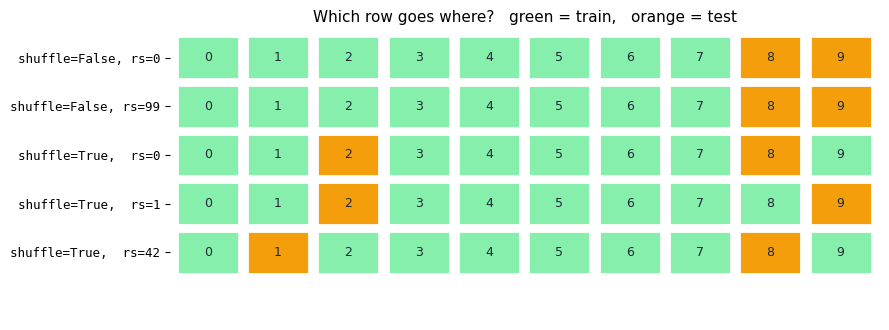

In [9]:
import matplotlib.pyplot as plt

configs = [
    ("shuffle=False, rs=0",   dict(test_size=0.2, random_state=0,  shuffle=False)),
    ("shuffle=False, rs=99",  dict(test_size=0.2, random_state=99, shuffle=False)),
    ("shuffle=True,  rs=0",   dict(test_size=0.2, random_state=0)),
    ("shuffle=True,  rs=1",   dict(test_size=0.2, random_state=1)),
    ("shuffle=True,  rs=42",  dict(test_size=0.2, random_state=42)),
]

fig, ax = plt.subplots(figsize=(9, 3.4))

for row, (label, kw) in enumerate(configs):
    held_out = test_rows(**kw)
    for col in range(len(X)):
        is_test = col in held_out
        ax.add_patch(plt.Rectangle((col, -row), 0.88, 0.88,
                                   facecolor="#f59e0b" if is_test else "#86efac",
                                   edgecolor="white", linewidth=2))
        ax.text(col + 0.44, -row + 0.44, str(col),
                ha="center", va="center", fontsize=9, color="#1f2937")

ax.set_xlim(-0.1, len(X)); ax.set_ylim(-len(configs) + 0.05, 1.0)
ax.set_yticks([-r + 0.44 for r in range(len(configs))])
ax.set_yticklabels([c[0] for c in configs], fontsize=9, family="monospace")
ax.set_xticks([]); ax.set_frame_on(False)
ax.set_title("Which row goes where?   green = train,   orange = test", fontsize=11)
plt.tight_layout()
plt.show()

## Visualisation 2 — the same split on the real data

The grid above shows *positions*. This shows the actual `Age` and `Income` values, so
you can see **what kind of people** end up in the test set.

With `shuffle=False` the test set is whatever sits at the end of the file. With
`shuffle=True` it is drawn from across the range.


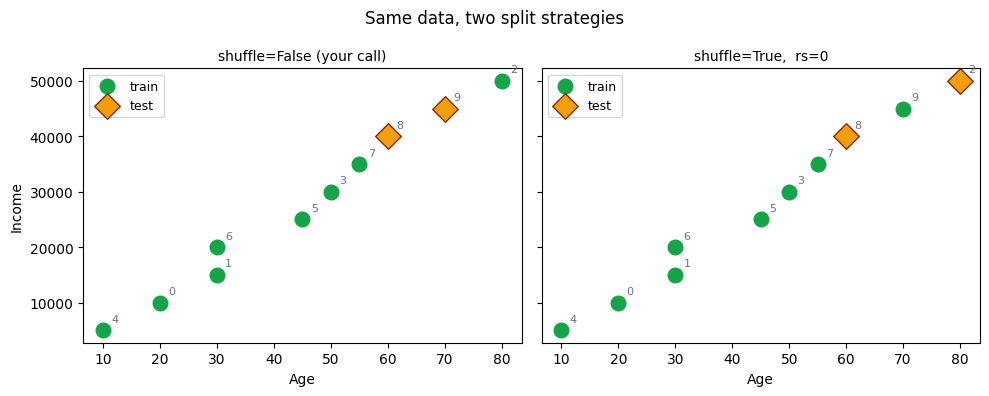

In [10]:
pairs = [
    ("shuffle=False (your call)", dict(test_size=0.2, random_state=0, shuffle=False)),
    ("shuffle=True,  rs=0",       dict(test_size=0.2, random_state=0)),
]

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharex=True, sharey=True)

for ax, (label, kw) in zip(axes, pairs):
    held_out  = test_rows(**kw)
    kept      = [i for i in X.index if i not in held_out]
    ax.scatter(X.loc[kept],     Y.loc[kept],     s=110, c="#16a34a", label="train")
    ax.scatter(X.loc[held_out], Y.loc[held_out], s=170, c="#f59e0b",
               marker="D", edgecolor="#7c2d12", label="test")
    for i in X.index:
        ax.annotate(str(i), (X.loc[i], Y.loc[i]), fontsize=8,
                    xytext=(6, 6), textcoords="offset points", color="#6b7280")
    ax.set_title(label, fontsize=10)
    ax.set_xlabel("Age")
    ax.legend(loc="upper left", fontsize=9)

axes[0].set_ylabel("Income")
fig.suptitle("Same data, two split strategies", fontsize=12)
plt.tight_layout()
plt.show()

## Experiment 3 — `test_size` controls how much you hold back

`test_size=0.2` means 20% of rows go to test. With 10 rows that is 2.

The trade-off is real and has no perfect answer:

- **Too small a test set** — the score is noisy. With 2 rows, one unusual person swings
  your accuracy by 50%.
- **Too large a test set** — the model has less to learn from and looks worse than it is.

`0.2` and `0.25` are the usual defaults. On a genuinely small dataset like this one,
neither is really enough, and cross-validation is the proper answer. That comes later.


test_size=0.1  ->  train 9 rows, test 1 rows
test_size=0.2  ->  train 8 rows, test 2 rows
test_size=0.3  ->  train 7 rows, test 3 rows
test_size=0.5  ->  train 5 rows, test 5 rows


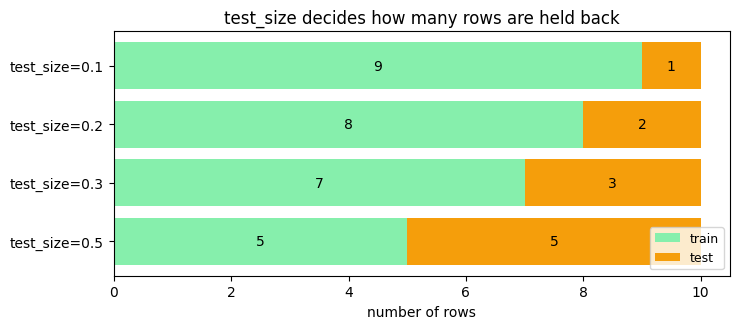

In [11]:
sizes = [0.1, 0.2, 0.3, 0.5]
counts = []

for ts in sizes:
    X_tr, X_te, _, _ = train_test_split(X, Y, test_size=ts, random_state=0)
    counts.append((len(X_tr), len(X_te)))
    print(f"test_size={ts}  ->  train {len(X_tr)} rows, test {len(X_te)} rows")

labels = [f"test_size={s}" for s in sizes]
train_n = [c[0] for c in counts]
test_n  = [c[1] for c in counts]

fig, ax = plt.subplots(figsize=(7.5, 3.4))
ax.barh(labels, train_n, color="#86efac", label="train")
ax.barh(labels, test_n, left=train_n, color="#f59e0b", label="test")

for i, (a, b) in enumerate(counts):
    ax.text(a / 2,     i, str(a), ha="center", va="center", fontsize=10)
    ax.text(a + b / 2, i, str(b), ha="center", va="center", fontsize=10)

ax.set_xlabel("number of rows")
ax.set_title("test_size decides how many rows are held back")
ax.legend(loc="lower right", fontsize=9)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## Gotcha — `stratify` cannot work without shuffling

`stratify` keeps the balance of a class column the same in both parts. If 30% of your
rows are "fraud", stratifying keeps 30% fraud in train **and** in test.

It needs to choose rows freely to do that, so it cannot run on an ordered slice.
Combining it with `shuffle=False` raises an error rather than quietly misbehaving —
which is the good kind of API design.


In [12]:
try:
    train_test_split(X, Y, test_size=0.2, shuffle=False, stratify=Y)
except ValueError as e:
    print("ValueError:", e)

ValueError: Stratified train/test split is not implemented for shuffle=False


## What this means for your code

```python
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=0, shuffle=False)
```

The call is correct and it runs. Two observations, not corrections:

1. **`random_state=0` is doing nothing here**, because `shuffle=False` turns shuffling
   off. Keeping both is harmless but misleading to a reader — it looks like a
   reproducible random split when it is actually a fixed slice. Either drop
   `random_state`, or drop `shuffle=False` and let the seed matter.
2. **`shuffle=False` on ordinary tabular data is usually not what you want.** It is the
   right choice for time series. For this dataset, the default `shuffle=True` gives a
   more representative test set.

Try removing `shuffle=False` from your cell above and re-running the prints. Compare the
index numbers to Visualisation 1.

## Common mistakes

| Mistake | What goes wrong |
|---|---|
| Unpacking as `X_train, y_train, X_test, y_test` | Returns are `X, X, y, y`. No error is raised — you just train on the wrong arrays. |
| Splitting after scaling or encoding | The transformer already saw the test rows. This is **data leakage** and your score becomes a lie. Split first, always. |
| Changing `random_state` until the score improves | You are now fitting to the test set. Fix the seed once and leave it. |
| Passing `shuffle=False` on sorted data | The test set is a biased slice of whatever the file ends with. |
| Using `stratify` on a continuous target | It only makes sense for classes. On `Income` it would try to balance 10 distinct values. |

## Key takeaway

**If you remember only one thing:** `train_test_split` returns
**`X_train, X_test, y_train, y_test` in that order**, and `random_state` only means
anything when `shuffle=True`. Split before you learn anything from the data — including
scaling and encoding — or the test set stops being a test.
